# 解答例（教員用）　第13回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第13回　学習曲線とハイパーパラメータ
***
> **前提**: 第6回の交差検証を発展させ，過学習の判断方法を学びます。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや特徴量を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
> | **【指示書】** | 知識を LLM に渡す | 実験で得た知識を、LLM が使える「指示書」に書き起こし、LLM の出力を自分のログで採点する |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="min_samples_leaf", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データ内の交差検証 CV）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. learning_curve
2. validation_curve
3. 交差検証の復習
4. 過学習の判断
5. 実験で得た知識を LLM への指示書にする【指示書】

---

## この回で学ぶこと

### バイアスとバリアンスのトレードオフ

機械学習モデルの「誤差」は2種類に分解できる：

```
汎化誤差 = バイアス² + バリアンス + ノイズ

【高バイアス（Underfitting）】
  モデルが単純すぎ → 訓練データにすら当てはまらない
  → 訓練スコア低，テストスコア低
  → 解決策：モデルを複雑にする（max_depth を増やすなど）

【高バリアンス（Overfitting）】
  モデルが複雑すぎ → 訓練データは完璧だが，テストデータは失敗
  → 訓練スコア高，テストスコア低（大きく差がある）
  → 解決策：正則化，データを増やす，モデルを単純にする
```

### 学習曲線（Learning Curve）

**訓練データのサイズを変えながら，訓練スコアとテストスコアの変化をプロットしたもの**。

```
【良い学習曲線のパターン】
訓練スコア  ↓  ̄ ̄ ̄\        ← データが増えると訓練スコアは少し下がる
検証スコア  /          ← データが増えると検証スコアは上がる
           両者が収束 → underfittingもoverfittingもない

【過学習の場合】
訓練スコア  ̄ ̄ ̄ ̄ ̄ ̄（高いまま）
検証スコア  ___________（低いまま，差が大きい）
```

- データが少ない時に大きな差がある：正則化またはデータ収集が必要
- データが多くなっても差が縮まらない：モデルが複雑すぎ

### 検証曲線（Validation Curve）

**ハイパーパラメータを変化させながら，訓練スコアと検証スコアをプロット**。最適なハイパーパラメータを視覚的に選ぶための手法だ。

```
【決定木の max_depth の場合】
max_depth が小さい：高バイアス（underfitting）
max_depth が大きい：高バリアンス（overfitting）
最適 max_depth：検証スコアが最大になる点
```

### 交差検証（Cross-Validation）の重要性

単一の train/test 分割では，その分割方法に結果が依存してしまう（運次第）。**k-fold 交差検証** はデータをk個に分割し，各分割でテストデータを入れ替えてk回評価することで，より安定した評価ができる。

> **卒業研究での指針**: 論文でハイパーパラメータを報告する際は，必ず「どのデータで選んだか（交差検証 or テストデータ）」を明記すること。テストデータでハイパーパラメータを選ぶと**テストデータのリーク**になる。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 全分野の機械学習研究 | モデル選択，過学習の診断，「データをあと何件集めればよいか」の判断 |
| 医学・生物学 | サンプル数が限られる研究での学習曲線分析 |
| 工学 | センサーデータのモデル複雑度チューニング（`max_depth` など） |
| 論文査読 | 学習曲線・検証曲線がないと「過学習を確認していない」と指摘されやすい |

### 応用できる場面

- **過学習か未学習かを判断**したい（訓練スコアと検証スコアのギャップ）
- **ハイパーパラメータの最適値**を体系的に探したい（検証曲線，GridSearchCV）
- **データ収集の費用対効果**を検討（学習曲線がまだ上昇中なら，データ追加が有効かも）
- 卒論・論文で**実験設計の説得力**を高めたい

### 応用しにくい・向かない場面

- **大規模事前学習モデル**（BERT，GPT など）のファインチューニング— 評価の枠組みが異なる（エポック数，学習率スケジュールなど）
- **オンライン学習・継続学習**（データが順次届く）— 静的な learning_curve とは別設計
- 検証曲線の**1点だけ**を見て結論づける（曲線全体の形状が重要）
- テストデータでハイパーパラメータを選ぶ（**リーク**— 本回で強調した最重要禁忌）

### 研究で報告するときのポイント

1. **学習曲線**と**検証曲線**（または validation curve）の図を論文に載せる
2. ハイパーパラメータは**交差検証**で選び，最終性能だけを**未使用のテストデータ**で報告
3. 「高バイアス / 高バリアンス」のどちらかを言語で説明し，**対策**（正則化，データ追加，モデル簡素化）を述べる
4. `GridSearchCV` の探索範囲と評価指標を Methods に書く

### 関連する発展トピック（調べてみると良い）

- Nested cross-validation（ハイパーパラメータ選択のバイアスをさらに抑える）
- Optuna / Bayesian optimization（探索の効率化）
- Early stopping（深層学習での過学習防止— 第15回以降と連動）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, learning_curve, validation_curve, train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier


def load_noisy_breast_cancer(noise=0.15, seed=0):
    """乳がんデータの診断ラベルのうち noise の割合を、わざと反転して返す（入力ミス・誤診断のあるラベルを模している）。
    元のままだと簡単すぎて、どの設定でも検証スコアが 0.93 前後になり、ハイパーパラメータの効き方が見えないため。"""
    d = load_breast_cancer()
    y = d.target.copy()
    flip = np.random.RandomState(seed).rand(len(y)) < noise
    y[flip] = 1 - y[flip]
    return d.data, y


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV など）」だけを記録する。テストデータは final_test() で1回だけ。
    ・bounds = {パラメータ名: (下限, 上限)} … それ以上広げられない値（例：k の下限 2）。ベストがここにあっても「端」と警告しない。
    ・ignore = {パラメータ名: [値, ...]} … 範囲の計算から外す特別な値（例：正則化なしを表す alpha=0）。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True, bounds=None, ignore=None):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.bounds, self.ignore = bounds or {}, ignore or {}
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows if r["params"][k] not in self.ignore.get(k, [])]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if k != "seed" and vals and len(nums) == len(vals) and len(set(nums)) > 2:
                lo, hi = min(nums), max(nums)
                blo, bhi = self.bounds.get(k, (None, None))
                bv = b["params"][k]
                edge = (bv == lo and lo != blo) or (bv == hi and hi != bhi)
                line += f"（範囲 {lo:g}〜{hi:g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn, name="最終テストスコア", compare=True):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。
        compare=False は、検証スコアと別の指標で評価するとき（並べて比べられないので表示しない）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"{name} = {self.test_result:.4f}"
              + (f"   （検証ベスト {self.score_name} = {self.best()['score']:.4f}）" if compare else ""))
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　学習曲線の描画　【説明】
***

### `cv=5` の意味

`cv=5` は5分割交差検証を意味する。各訓練サイズで：
1. データを5つに分割
2. 4つを訓練，1つを検証に使って評価
3. これを5回繰り返し，5つのスコアの平均と標準偏差を算出

`train_scores` の shape は `(train_sizes の個数, cv=5)` になる。そのため `np.mean(train_scores, axis=1)` で各サイズの平均を取る。

### 標準偏差の帯を描く方法

各点での不確かさ（ばらつき）を帯として描くと，グラフの信頼性が上がる：

```python
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
```

論文やレポートではこのような信頼区間を付けることが推奨される。

### 課題

下のコードセルは，乳がんデータで `learning_curve` を計算して学習曲線を描画する **完成形**です。今回は自分でコードを書くのではなく，**`learning_curve` が何を返し，訓練スコアと検証スコアの差が何を意味するのかを読み解く**のが目的です。

**各行の `# 説明:` の右に，その行が何をしているかを自分の言葉で書いて**ください（コード自体は変更しないこと）。書き終えたらセルを実行し，学習曲線を観察してください。

説明を書くときは，次の問いを意識してください：

- `learning_curve` が返す `train_scores` と `valid_scores` は，それぞれ何を測ったスコアか？
- `train_scores` の shape はなぜ `(訓練サイズ数, cv数)` なのか？ なぜ `axis=1` 方向に平均を取るのか？
- 訓練スコアと検証スコアの **差** が大きいことは，モデルの状態について何を意味するのか？

> **観察ポイント**: 訓練データを増やすほど，訓練スコアと検証スコアの差は縮まりましたか？ 縮まらない場合、それは何を示唆しますか？（解答用コードセルに記入）

### まずデータの中身を見てみよう（実行するだけ）

乳がんデータです．腫瘍の細胞核の特徴 30 個から良性/悪性を予測します．

**この回では，診断ラベルのうち 15% をわざと反転させたデータ（`load_noisy_breast_cancer()`）を使います**．現実のデータには入力ミスや誤診断が混ざります．元のままの乳がんデータは簡単すぎて，どんな決定木でも検証スコアが 0.93 前後になり，「過学習」と「ちょうど良い複雑さ」の違いが見えません．ラベルに誤りがあると，**深い木は誤りまで暗記してしまう**ため，複雑さの選び方がはっきり結果に表れます．（ラベルの 15% が誤りなので，どんなに良いモデルでも正解率はおよそ 0.85 が上限の目安です．）

In [2]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
_bc = load_breast_cancer()
print("形状（件数, 特徴量数）:", _bc.data.shape)
print("特徴量名（先頭 6 個）:", list(_bc.feature_names[:6]))
print("クラス名:", list(_bc.target_names), " 件数:", dict(zip(_bc.target_names, np.bincount(_bc.target))))
print("\n先頭 3 件の最初の 5 特徴量:")
print(np.round(_bc.data[:3, :5], 2))

形状（件数, 特徴量数）: (569, 30)
特徴量名（先頭 6 個）: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness']
クラス名: ['malignant', 'benign']  件数: {'malignant': 212, 'benign': 357}

先頭 3 件の最初の 5 特徴量:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.200e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.000e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.100e-01]]


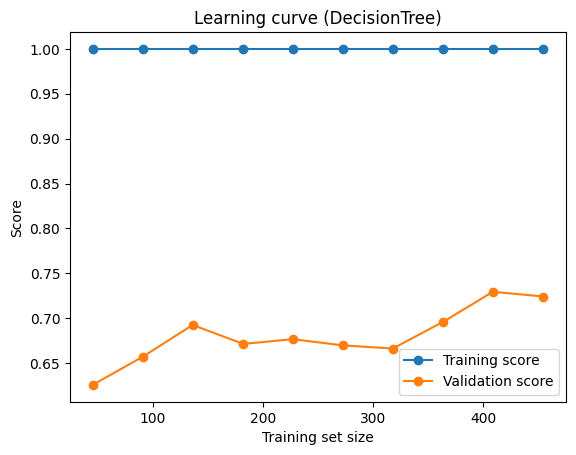

最大サイズでの 訓練-検証 の差 = 0.2759


In [3]:
# 各行の「# 説明:」に自分の言葉で意味を書いてください（コードは変更しない）
# （説明は AI に書かせず、自分で書くこと）

X, y = load_noisy_breast_cancer()                                                       # 説明:（load_noisy_breast_cancer は最初のセルで定義。ラベルの15%が誤り） 乳がんデータの説明変数 X（30 特徴量）と目的変数 y（良性/悪性）を取り出す．

model = DecisionTreeClassifier(random_state=0)             # 説明: 深さ無制限の決定木（過学習しやすいモデル）を作る．random_state=0 で結果を再現可能にする．

train_sizes, train_scores, valid_scores = learning_curve(  # 説明: 訓練データのサイズを変えながら交差検証を行い，訓練サイズ（train_sizes），各サイズでの訓練スコア（train_scores），検証スコア（valid_scores）の 3 つを返す．
    model, X, y,
    cv=5,                                                  # 説明: 5 分割交差検証．データを 5 つに分け，4 つで学習・1 つで検証するのを 5 回繰り返す．
    train_sizes=np.linspace(0.1, 1.0, 10),                 # 説明: 訓練に使うデータの割合を 0.1 から 1.0 まで 10 段階（10%, 20%, …, 100%）に変える．
)

train_mean = np.mean(train_scores, axis=1)                 # 説明: train_scores の形は (訓練サイズ数, cv 数)．axis=1（列方向＝cv の 5 回）で平均をとり，訓練サイズごとの平均訓練スコアにする．
valid_mean = np.mean(valid_scores, axis=1)                 # 説明: 同様に，検証スコアを cv の 5 回で平均し，訓練サイズごとの平均検証スコアにする．

plt.plot(train_sizes, train_mean, "o-", label="Training score")   # 説明: 横軸に訓練サイズ，縦軸に平均訓練スコアの線を描く．
plt.plot(train_sizes, valid_mean, "o-", label="Validation score")   # 説明: 横軸に訓練サイズ，縦軸に平均検証スコアの線を描く．
plt.xlabel("Training set size")
plt.ylabel("Score")
plt.title("Learning curve (DecisionTree)")
plt.legend()
plt.show()

# 訓練データが最大のときの「訓練スコア - 検証スコア」の差
gap = train_mean[-1] - valid_mean[-1]                      # 説明: 訓練データが最大のときの訓練スコアと検証スコアの差．大きいほど訓練データだけに適合した過学習の度合いが大きい．
print(f"最大サイズでの 訓練-検証 の差 = {gap:.4f}")


In [4]:
# === ✍️ 問題1 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (1-a) `learning_curve` が返す `train_scores` と `valid_scores` はそれぞれ何を測ったスコアか
answer_1_a = """
train_scores は各訓練サイズで「学習に使ったデータそのもの」を採点したスコア、valid_scores は「学習に使っていない検証用の分割」を採点したスコア。どちらも各訓練サイズ × 5 分割（cv）の値が入る。
"""

# (1-b) なぜ `axis=1` 方向に平均を取るのか
answer_1_b = """
train_scores・valid_scores の形は (訓練サイズ数, cv の分割数)。axis=1 は横方向（cv の 5 回）なので、各訓練サイズについて 5 回の分割のスコアを平均し、訓練サイズごとの代表値（グラフの 1 点）にするため。
"""

# (1-c) 訓練スコアと検証スコアの「差」が大きいことは、モデルの状態について何を意味するか
answer_1_c = """
差（訓練 − 検証）が大きい＝訓練データにだけ当てはまり、未知のデータで性能が落ちる状態＝過学習（高バリアンス）。差が小さいのに両方低いなら未学習（高バイアス）。
"""

# (1-d) 観察：訓練データを増やすと差は縮まったか／縮まらない場合それは何を示唆するか
observation_1_d = """
訓練スコアはどの訓練サイズでも 1.0（深さ無制限の木は、誤ったラベルまで含めて訓練データを完全に暗記する）。検証スコアは 45 件で 0.626、455 件で 0.724 と少し上がったが、最大サイズでも差は 0.2759 と大きく、ほとんど縮まっていない。データを増やすだけでは解決せず、モデルの複雑さを制限する（深さ・葉の大きさ・枝刈り）必要があることを示唆する。ラベルの 15% が誤りなので、暗記するほど誤りまで覚えてしまう。
"""


## 問題2　決定木の最適設定を自分で探す　【探索】
***

### 課題

第13回の主題は「**過学習を見抜き、検証スコアで設定を選ぶ**」ことです。問題1の学習曲線で「深い決定木は訓練を暗記する」ことを見ました。ここでは **検証スコア（訓練データ内の 5 分割 CV）が高い決定木の設定**を、自分で探します。

| 軸 | 選択肢 | 意味 |
|---|---|---|
| `max_depth` | 1〜10、`50`（**実質制限なし**。`None` の代わり） | 木の深さの上限 |
| `min_samples_leaf` | 1〜30 など | 葉に必要な最小サンプル数（大きいほど単純） |
| `ccp_alpha` | 0（枝刈りなし）〜 0.05 など | コスト複雑度枝刈り。大きいほど枝を刈って単純にする |
| `criterion` | `"gini"` / `"entropy"` | 分岐の良さの測り方 |

各試行では `cv_score`（検証スコア）に加え、`train_acc` と `gap = train_acc - cv_score`（過学習の度合い）を記録します。

### 「差が偶然かどうか」を意識する

乳がんデータは 569 件と小さく（しかもラベルの 15% が誤り）、`cv_std`（CV 5 回のばらつき）は 0.01〜0.04 あります。**上位の設定同士の差が `cv_std` 以内なら「差がある」とは言えません**。その場合、**最良から標準偏差以内で最も単純なモデル**を選ぶ（1 標準偏差ルール）のが定石です。

### 課題

1. **【実験前に先に書く】** 予測セルに、最良の `max_depth` の範囲・最も効く軸・理由を書く。
2. 探索セルの `hypothesis` と `settings` を書き換えて何度も実行（**15回以上**、3軸以上を動かす）。**核心（CV 評価の1行）はあなたが書きます**。
3. 経過確認セルで、gap の推移・端・頭打ちを確認する。
4. 解答セルに書く。**テストデータの最終評価は問題4でまとめて 1回だけ**行います（ここでは見ない）。

> **観察ポイント**: `max_depth` を大きくすると `gap` はどう変わりましたか？ 検証スコアが最大の設定は、他の設定と `cv_std` を超えて差がありましたか？

In [5]:
# === ✍️ 問題2-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 検証スコアが最大になると思う max_depth（数値）と、最も効くと思う軸（max_depth / min_samples_leaf / ccp_alpha / criterion）
prediction_2_depth = 4
prediction_2_axis = "max_depth"
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
決定木では max_depth が過学習に最も直接効くと考えた。乳がんデータは 569 件と少なく、ラベルの 15% が誤りなので、深さ 3〜5 程度に制限した木が最良になるだろうと予想した（LLM に聞いても「max_depth は 3〜5、min_samples_leaf は 5〜10」）。
"""

In [6]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
X, y = load_noisy_breast_cancer()   # ラベルの15%が誤り（最初のセルで定義）
# テストデータ（X_test）は問題4の最終評価まで一切使わない
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
lab = Lab("q13_tree", score_name="cv_score",
          bounds={"max_depth": (1, 50), "min_samples_leaf": (1, None), "ccp_alpha": (0.0, None)})

def run_trial(hypothesis, depth, leaf, ccp, criterion):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"max_depth": depth, "min_samples_leaf": leaf, "ccp_alpha": ccp, "criterion": criterion}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, ccp_alpha=ccp,
                                  criterion=criterion, random_state=0)
    # ★あなたが書く★：訓練データ内の5分割CVで正解率を5つ求める（1行）。テストデータは使わない
    #   ヒント: cross_val_score(tree, 説明変数, 目的変数, cv=cv5, scoring="accuracy")
    scores = cross_val_score(tree, X_train, y_train, cv=cv5, scoring="accuracy")
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    lab.log(hypothesis, params, scores.mean(),
            cv_std=round(scores.std(), 4), train_acc=round(train_acc, 4),
            gap=round(train_acc - scores.mean(), 4), n_leaves=tree.get_n_leaves())

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (max_depth, min_samples_leaf, ccp_alpha, criterion)
#       max_depth … 木の深さの上限（1〜10。50 は実質「制限なし」の意味で None の代わり）
#       min_samples_leaf … 葉に必要な最小サンプル数（1〜30）
#       ccp_alpha … 枝刈りの強さ（0.0 = 刈らない〜0.05）
#       criterion … "gini" / "entropy"
#     行を足す／消す／数値を書き換えてよい。例：settings = [(d, 1, 0.0, "gini") for d in (1, 2, 3, 5, 10, 50)]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。3 軸以上を動かすこと。
# 進め方の例： ①max_depth を広く振る → ②他の軸（leaf / ccp_alpha / criterion）を動かす → ③良い範囲を細かく
hypothesis = "max_depth を 1〜50 まで振り、gap（過学習）が開き始める深さと検証スコアの山を見る"
settings = [                       # (max_depth, min_samples_leaf, ccp_alpha, criterion)
    (d, 1, 0.0, "gini") for d in (1, 2, 3, 5, 10, 50)
]
for depth, leaf, ccp, crit in settings:
    run_trial(hypothesis, depth, leaf, ccp, crit)

  #01 {'max_depth': 1, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7802  cv_std=0.0155  train_acc=0.8044  gap=0.0242  n_leaves=2  ★ベスト更新
  #02 {'max_depth': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8044  cv_std=0.0235  train_acc=0.8308  gap=0.0264  n_leaves=4  ★ベスト更新
  #03 {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8154  cv_std=0.0108  train_acc=0.8462  gap=0.0308  n_leaves=8  ★ベスト更新
  #04 {'max_depth': 5, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7626  cv_std=0.0338  train_acc=0.8813  gap=0.1187  n_leaves=17
  #05 {'max_depth': 10, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7473  cv_std=0.0251  train_acc=0.9714  gap=0.2242  n_leaves=51


  #06 {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7165  cv_std=0.0176  train_acc=1.0  gap=0.2835  n_leaves=67


In [7]:
hypothesis = "深さ無制限（50）のまま min_samples_leaf を大きくすると過学習が減るか"
settings = [(50, l, 0.0, "gini") for l in (2, 5, 10, 20)]
for depth, leaf, ccp, crit in settings:
    run_trial(hypothesis, depth, leaf, ccp, crit)

  #07 {'max_depth': 50, 'min_samples_leaf': 2, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7165  cv_std=0.0396  train_acc=0.9758  gap=0.2593  n_leaves=50
  #08 {'max_depth': 50, 'min_samples_leaf': 5, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7209  cv_std=0.0499  train_acc=0.9077  gap=0.1868  n_leaves=38
  #09 {'max_depth': 50, 'min_samples_leaf': 10, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7407  cv_std=0.0588  train_acc=0.8681  gap=0.1275  n_leaves=25
  #10 {'max_depth': 50, 'min_samples_leaf': 20, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8066  cv_std=0.0283  train_acc=0.8198  gap=0.0132  n_leaves=17


,trial,max_depth,min_samples_leaf,ccp_alpha,criterion,cv_score,cv_std,train_acc,gap,n_leaves
2,3,3,1,0.0,gini,0.8154,0.0108,0.8462,0.0308,8
9,10,50,20,0.0,gini,0.8066,0.0283,0.8198,0.0132,17
1,2,2,1,0.0,gini,0.8044,0.0235,0.8308,0.0264,4
0,1,1,1,0.0,gini,0.7802,0.0155,0.8044,0.0242,2
3,4,5,1,0.0,gini,0.7626,0.0338,0.8813,0.1187,17
4,5,10,1,0.0,gini,0.7473,0.0251,0.9714,0.2242,51
8,9,50,10,0.0,gini,0.7407,0.0588,0.8681,0.1275,25
7,8,50,5,0.0,gini,0.7209,0.0499,0.9077,0.1868,38


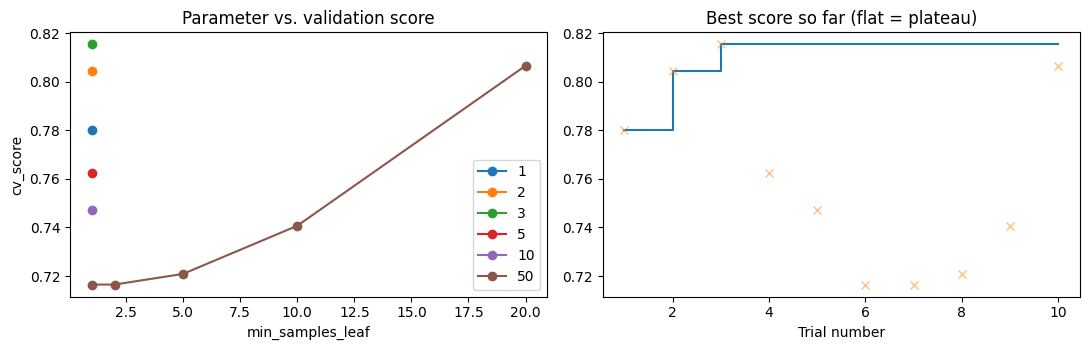

■ 試行回数: 10（目安 15 回以上） → まだ足りない
■ ベスト: trial#3 {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8154
■ max_depth: 6 種類を試した（範囲 1〜50）
■ min_samples_leaf: 5 種類を試した（範囲 1〜20）
■ ccp_alpha: 1 種類を試した
■ criterion: 1 種類を試した
■ 仮説を書いた試行: 10/10
■ 前半の最高 0.8154 → 後半の最高 0.8066
最良から cv_std 以内の設定数: 2 / 10  ← 差が偶然の範囲の設定がこれだけある
その中で葉の数が最少（＝最も単純）: {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}


In [8]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="min_samples_leaf", group="max_depth", logx=False)     # 設定と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)
b = lab.best()
near = [r for r in lab.rows if r["score"] >= b["score"] - b["extra"]["cv_std"]]
print(f"最良から cv_std 以内の設定数: {len(near)} / {len(lab.rows)}  ← 差が偶然の範囲の設定がこれだけある")
print("その中で葉の数が最少（＝最も単純）:", min(near, key=lambda r: r["extra"]["n_leaves"])["params"])

In [9]:
hypothesis = "コスト複雑度枝刈り ccp_alpha で単純化するとどうなるか（深さ無制限のまま）"
settings = [(50, 1, c, "gini") for c in (0.002, 0.005, 0.01, 0.02)]
for depth, leaf, ccp, crit in settings:
    run_trial(hypothesis, depth, leaf, ccp, crit)

  #11 {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.002, 'criterion': 'gini'}  cv_score=0.7165  cv_std=0.0176  train_acc=1.0  gap=0.2835  n_leaves=67
  #12 {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.005, 'criterion': 'gini'}  cv_score=0.7341  cv_std=0.0235  train_acc=0.9121  gap=0.178  n_leaves=21
  #13 {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.01, 'criterion': 'gini'}  cv_score=0.8044  cv_std=0.0264  train_acc=0.8396  gap=0.0352  n_leaves=5


  #14 {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.02, 'criterion': 'gini'}  cv_score=0.8066  cv_std=0.0266  train_acc=0.8242  gap=0.0176  n_leaves=3


,trial,max_depth,min_samples_leaf,ccp_alpha,criterion,cv_score,cv_std,train_acc,gap,n_leaves
2,3,3,1,0.00,gini,0.8154,0.0108,0.8462,0.0308,8
9,10,50,20,0.00,gini,0.8066,0.0283,0.8198,0.0132,17
13,14,50,1,0.02,gini,0.8066,0.0266,0.8242,0.0176,3
1,2,2,1,0.00,gini,0.8044,0.0235,0.8308,0.0264,4
12,13,50,1,0.01,gini,0.8044,0.0264,0.8396,0.0352,5
0,1,1,1,0.00,gini,0.7802,0.0155,0.8044,0.0242,2
3,4,5,1,0.00,gini,0.7626,0.0338,0.8813,0.1187,17
4,5,10,1,0.00,gini,0.7473,0.0251,0.9714,0.2242,51


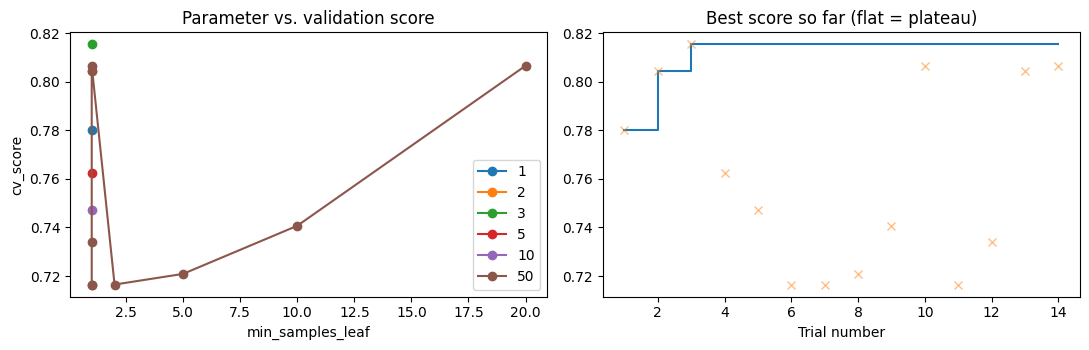

■ 試行回数: 14（目安 15 回以上） → まだ足りない
■ ベスト: trial#3 {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8154
■ max_depth: 6 種類を試した（範囲 1〜50）
■ min_samples_leaf: 5 種類を試した（範囲 1〜20）
■ ccp_alpha: 5 種類を試した（範囲 0〜0.02）
■ criterion: 1 種類を試した
■ 仮説を書いた試行: 14/14
■ 前半の最高 0.8154 → 後半の最高 0.8066
最良から cv_std 以内の設定数: 3 / 14  ← 差が偶然の範囲の設定がこれだけある
その中で葉の数が最少（＝最も単純）: {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.02, 'criterion': 'gini'}


In [10]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="min_samples_leaf", group="max_depth", logx=False)     # 設定と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)
b = lab.best()
near = [r for r in lab.rows if r["score"] >= b["score"] - b["extra"]["cv_std"]]
print(f"最良から cv_std 以内の設定数: {len(near)} / {len(lab.rows)}  ← 差が偶然の範囲の設定がこれだけある")
print("その中で葉の数が最少（＝最も単純）:", min(near, key=lambda r: r["extra"]["n_leaves"])["params"])

In [11]:
hypothesis = "最良付近（depth 3〜5）の周辺で、葉のサイズ・criterion を確認する"
settings = [(4, 1, 0.0, "gini"), (4, 5, 0.0, "gini"), (3, 5, 0.0, "gini"), (3, 1, 0.0, "entropy"), (5, 1, 0.0, "entropy")]
for depth, leaf, ccp, crit in settings:
    run_trial(hypothesis, depth, leaf, ccp, crit)

  #15 {'max_depth': 4, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7912  cv_std=0.0231  train_acc=0.8571  gap=0.0659  n_leaves=12
  #16 {'max_depth': 4, 'min_samples_leaf': 5, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.7868  cv_std=0.0247  train_acc=0.8462  gap=0.0593  n_leaves=11
  #17 {'max_depth': 3, 'min_samples_leaf': 5, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8088  cv_std=0.0149  train_acc=0.8396  gap=0.0308  n_leaves=8
  #18 {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'entropy'}  cv_score=0.7956  cv_std=0.033  train_acc=0.8462  gap=0.0505  n_leaves=8
  #19 {'max_depth': 5, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'entropy'}  cv_score=0.7473  cv_std=0.0428  train_acc=0.8703  gap=0.1231  n_leaves=18


,trial,max_depth,min_samples_leaf,ccp_alpha,criterion,cv_score,cv_std,train_acc,gap,n_leaves
2,3,3,1,0.00,gini,0.8154,0.0108,0.8462,0.0308,8
16,17,3,5,0.00,gini,0.8088,0.0149,0.8396,0.0308,8
9,10,50,20,0.00,gini,0.8066,0.0283,0.8198,0.0132,17
13,14,50,1,0.02,gini,0.8066,0.0266,0.8242,0.0176,3
1,2,2,1,0.00,gini,0.8044,0.0235,0.8308,0.0264,4
12,13,50,1,0.01,gini,0.8044,0.0264,0.8396,0.0352,5
17,18,3,1,0.00,entropy,0.7956,0.0330,0.8462,0.0505,8
14,15,4,1,0.00,gini,0.7912,0.0231,0.8571,0.0659,12


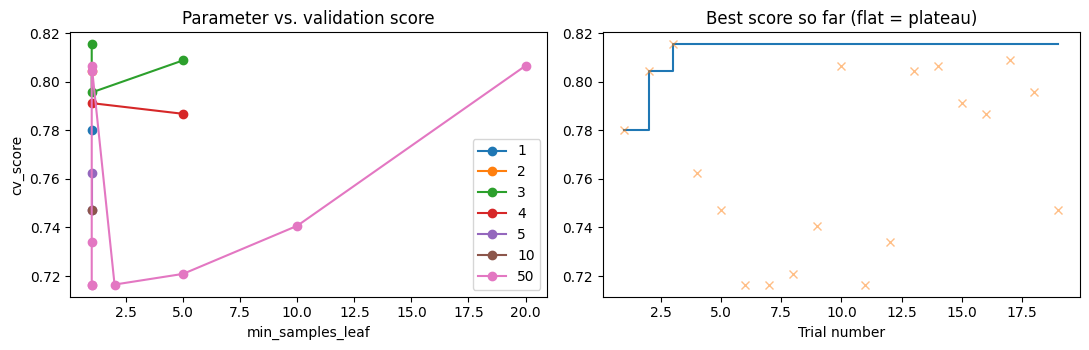

■ 試行回数: 19（目安 15 回以上） → OK
■ ベスト: trial#3 {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}  cv_score=0.8154
■ max_depth: 7 種類を試した（範囲 1〜50）
■ min_samples_leaf: 5 種類を試した（範囲 1〜20）
■ ccp_alpha: 5 種類を試した（範囲 0〜0.02）
■ criterion: 2 種類を試した
■ 仮説を書いた試行: 19/19
■ 前半の最高 0.8154 → 後半の最高 0.8088
最良から cv_std 以内の設定数: 4 / 19  ← 差が偶然の範囲の設定がこれだけある
その中で葉の数が最少（＝最も単純）: {'max_depth': 50, 'min_samples_leaf': 1, 'ccp_alpha': 0.02, 'criterion': 'gini'}


In [12]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("cv_score", ascending=False).head(8))
lab.plot(x="min_samples_leaf", group="max_depth", logx=False)     # 設定と CV 正解率、ベスト更新の推移
lab.report(min_trials=15)
b = lab.best()
near = [r for r in lab.rows if r["score"] >= b["score"] - b["extra"]["cv_std"]]
print(f"最良から cv_std 以内の設定数: {len(near)} / {len(lab.rows)}  ← 差が偶然の範囲の設定がこれだけある")
print("その中で葉の数が最少（＝最も単純）:", min(near, key=lambda r: r["extra"]["n_leaves"])["params"])

In [13]:
# === ✍️ 問題2 解答（採点対象）===
import pandas as pd

# (2-a) 実験ログ（自動出力。全試行が出力に残る。15回以上・3軸以上を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2-b) 探索の進め方：各段階で何を見て次の試行を決めたか（試行番号 #n を引用）
answer_2_b = """
【#1〜#6】min_samples_leaf=1 のまま max_depth を 1, 2, 3, 5, 10, 50 と振った。CV は 0.7802 → 0.8044 → 0.8154 → 0.7626 → 0.7473 → 0.7165 と depth=3 に山があり、深くすると大きく下がった。gap（訓練−CV）は 0.024 → 0.026 → 0.031 → 0.119 → 0.224 → 0.284 と、depth=5 から急に開いた。
【#7〜#10】深さ無制限のまま min_samples_leaf を 2, 5, 10, 20 に。CV は 0.7165 → 0.7209 → 0.7407 → 0.8066 と、leaf=20（#10）で depth=3 に近い値まで回復し、gap も 0.013 と最小。
【#11〜#14】深さ無制限のまま ccp_alpha を 0.002〜0.02 に。0.002（#11）は #6 と全く同じ（葉 67 個のまま、刈られる枝が無い）。0.01（#13: 0.8044, 葉 5）、0.02（#14: 0.8066, 葉 3）で大きく回復。
【#15〜#19】最良の depth=3 付近で leaf と criterion を確認。depth=4（#15: 0.7912）、depth=3・leaf=5（#17: 0.8088）、entropy（#18: 0.7956, #19: 0.7473）。depth=3 を超えない範囲で上位が cv_std 以内に並んだので終了した。
"""

# (2-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（#n を引用）
answer_2_c = """
仮説「max_depth は 3〜5 が最良」は半分外れた：depth=3（#3: 0.8154）は最良だが、depth=5（#4: 0.7626）は 0.053 も低く、depth=4（#15: 0.7912）でも下がった。ラベルに誤りがあるデータでは、1 段深くするだけで誤ったサンプルを分ける枝が増え、汎化性能が落ちる。
また「ccp_alpha を少しでも入れれば単純になる」も外れた：#11（ccp_alpha=0.002）は #6 と完全に同じ（葉 67 個）。ccp_alpha は「この値より効果の小さい枝を刈る」閾値なので、小さすぎると何も刈られない。cost_complexity_pruning_path で有効な桁（今回は 0.01 付近）を確認すべきだった。
"""

# (2-d) 観察：max_depth を大きくすると gap はどう変化したか／検証スコアが最大の max_depth（cv_std と比べて意味のある差か）
observation_2_d = """
max_depth を大きくすると gap は 0.024（depth1）→ 0.031（3）→ 0.119（5）→ 0.224（10）→ 0.284（50）と単調に広がった。CV が最大なのは depth=3 の 0.8154 ± 0.0108。depth=5（0.7626）や無制限（0.7165）との差 0.05〜0.10 は cv_std（0.01〜0.03）の数倍で、意味のある差と言える。一方、depth=2（0.8044 ± 0.0235）との差 0.011 は cv_std 以内で、2 と 3 のどちらが良いかは決められない。
"""

# (2-e) 観察：min_samples_leaf・ccp_alpha を大きくすると過学習（gap）と検証スコアはどうなったか（#n を引用）
observation_2_e = """
深さ無制限のまま min_samples_leaf を大きくする（#7〜#10）と gap は 0.259 → 0.013 に縮み、CV は 0.7165 → 0.8066 と 0.09 上がった（ただし leaf=5, 10 では cv_std が 0.05〜0.06 と不安定）。ccp_alpha を大きくする（#12〜#14）と葉は 21 → 5 → 3 個に減り、gap は 0.178 → 0.018、CV は 0.7341 → 0.8066 と同様に回復した。どちらも「深さ制限」とは別の方法で木を単純にし、深さ 3 の木（0.8154）とほぼ同じ所まで戻せた。
"""

# (2-f) 最良設定と、「最良から cv_std 以内で最も単純な設定」は同じか。どちらを採用するか、その理由
answer_2_f = """
最良は #3（max_depth=3, leaf=1, ccp=0, gini）で 0.8154 ± 0.0108、葉 8 個。最良から cv_std 以内（0.8046 以上）の設定は 19 中 4 個（#3, #17, #10, #14）で、その中で最も単純（葉 3 個）なのは #14（深さ無制限・ccp_alpha=0.02、CV 0.8066 ± 0.0266）。同じではない。1 標準偏差ルールに従い #14 を採用する。理由：CV の差（0.009）は cv_std 以内で偶然の範囲、葉が 3 個で解釈しやすく、gap も 0.018 と小さい。ただし #14 は cv_std が #3 の 2.5 倍あり、安定性を重視するなら #3 を選ぶ判断もあり得る。
"""

# (2-g) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_g = """
予測は max_depth=4 で、max_depth が最も効く。実際の CV 最良は depth=3（#3）で、depth=4（#15: 0.7912）は 0.024 低かった。max_depth が強く効く点は正しかった（depth 3 と 50 で 0.10 の差）。ズレたのは「どのくらい浅くすべきか」で、ラベル誤りのあるデータでは予想より浅い木が良かった。また、min_samples_leaf（#10）や ccp_alpha（#14）でも、深さ制限と同じくらい回復できることは予想していなかった。正しかった知識：深さ制限が gap を小さくする。新しく分かった知識：ccp_alpha は小さすぎると何も起きない（#11）。
"""


    trial  max_depth  min_samples_leaf  ccp_alpha criterion  cv_score  cv_std  train_acc     gap  n_leaves
0       1          1                 1      0.000      gini    0.7802  0.0155     0.8044  0.0242         2
1       2          2                 1      0.000      gini    0.8044  0.0235     0.8308  0.0264         4
2       3          3                 1      0.000      gini    0.8154  0.0108     0.8462  0.0308         8
3       4          5                 1      0.000      gini    0.7626  0.0338     0.8813  0.1187        17
4       5         10                 1      0.000      gini    0.7473  0.0251     0.9714  0.2242        51
5       6         50                 1      0.000      gini    0.7165  0.0176     1.0000  0.2835        67
6       7         50                 2      0.000      gini    0.7165  0.0396     0.9758  0.2593        50
7       8         50                 5      0.000      gini    0.7209  0.0499     0.9077  0.1868        38
8       9         50                1

## 問題3　過学習の診断と対処　【選択】
***

### 「訓練スコアと検証スコアの差が大きい」の意味

この状態を診断するために，問題1・2の学習曲線と検証曲線を見返そう：

- **差が大きい + 両者が収束しない**: 高バリアンス（過学習）。モデルが訓練データを「暗記」している状態
- **差が小さいが両者とも低い**: 高バイアス（過少適合）。モデルが単純すぎてパターンを学習できていない

対処法のまとめ：

| 問題 | 症状 | 対処法 |
|---|---|---|
| 過学習（高バリアンス） | 訓練高・テスト低 | 正則化，max_depth 制限，データ追加 |
| 過少適合（高バイアス） | 訓練低・テスト低 | モデルを複雑にする，特徴量を増やす |

### ハイパーパラメータの選び方

問題2では、検証スコア（訓練データ内の CV）を物差しにして決定木の設定を探した。このように「検証データ（またはクロスバリデーション）でハイパーパラメータを選ぶ」プロセスが正しい方法だ。**テストデータで選んではいけない**（次の問題4で実践する）。

### 課題

下のコードセルは前処理まで用意してありますが、**核心（決定木の学習と train/test 正解率の計算）はあなたが書きます**（`# ★あなたが書く★`）。実行すると，`max_depth` を制限しない決定木の **訓練正解率・検証正解率（CV）・その差（gap）** が出力されます。これを問題1の学習曲線・問題2の探索ログと合わせて見て，モデルの状態を **診断**してください。

> **設計判断（診断）**: いまのモデルは次のどちらの状態に近いですか？ 1つ選び、根拠（訓練スコア・検証スコア・gap の値）を解答用コードセルに書いてください。
>
> - **(状態1) 過学習（高バリアンス, high variance）** … 訓練スコアは高いが検証スコアが低く、gap が大きい
> - **(状態2) 未学習（高バイアス, high bias）** … 訓練スコアも検証スコアも低い（どちらも低い）

> **設計判断（対処）**: 上で選んだ状態に対して、**効果がありそうな対処を1つ以上選び**、それぞれ「なぜ効くと思うか」を解答用コードセルに書いてください。**やみくもに全部やるのではなく、診断結果に応じて選ぶ**のが大事です。
>
> - **(A) 正則化を強める / `max_depth` を小さく制限する**
> - **(B) 学習データを増やす**
> - **(C) 特徴量を減らす**
> - **(D) モデルを単純にする**
> - **(E) モデルを複雑にする（`max_depth` を増やす・特徴量を増やす）**
> - **(F) `min_samples_leaf` を大きくする（葉に必要な最小サンプル数を増やす）**
>
> ヒント：状態1（過学習）と状態2（未学習）では、選ぶべき対処が **逆向き**になります。各選択肢が「モデルを単純にする方向」か「複雑にする方向」か、それとも「データ側を変える」ものかを考えてから選んでください。

> **考察1**: 学習曲線が「**訓練もテストも低い**」場合と、「**訓練だけ高くテストが低い**」場合とで、「データを増やすべきか」「モデルを変えるべきか」の判断はどう変わりますか？ 解答用コードセルに書いてください。


In [14]:
# === 完成済みコード：そのまま実行し、出力（診断材料）を観察してください ===
X, y = load_noisy_breast_cancer()   # 問題2と同じデータ・同じ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)   # X_test は問題4の最終評価まで使わない

# max_depth を制限しない（＝複雑な）決定木で診断する
diag_model = DecisionTreeClassifier(random_state=0)
# ★あなたが書く★：diag_model を学習し、訓練正解率 train_acc と検証正解率 valid_acc（訓練データ内の5分割CVの平均）を求める（3行）
#   ヒント: .fit(X_train, y_train) で学習、.score(X, y) で訓練正解率、cross_val_score(diag_model, X_train, y_train, cv=5).mean() で検証正解率
diag_model.fit(X_train, y_train)
train_acc = diag_model.score(X_train, y_train)
valid_acc = cross_val_score(diag_model, X_train, y_train, cv=5).mean()

print(f"訓練正解率   = {train_acc:.4f}")
print(f"検証正解率（CV） = {valid_acc:.4f}")
print(f"差 gap       = {train_acc - valid_acc:.4f}")
print()
print("【診断の目安】")
print(" ・訓練高 / 検証低（gap 大）   → 過学習（高バリアンス）")
print(" ・訓練低 / 検証低（どちらも低い） → 未学習（高バイアス）")


訓練正解率   = 1.0000
検証正解率（CV） = 0.7099
差 gap       = 0.2901

【診断の目安】
 ・訓練高 / 検証低（gap 大）   → 過学習（高バリアンス）
 ・訓練低 / 検証低（どちらも低い） → 未学習（高バイアス）


In [15]:
# === ✍️ 問題3 解答（採点対象）===

# (3-a) 観察：訓練正解率 / 検証正解率（CV） / gap の値
observation_3_a = """
訓練正解率 = 1.0000、検証正解率（CV） = 0.7099、gap = 0.2901。
"""

# (3-b) 設計判断（診断）：いまのモデルの状態：( 状態1 過学習 / 状態2 未学習 )
answer_3_b = """
過学習（状態1）
"""

# (3-c) その根拠（上の値に触れて）
answer_3_c = """
訓練正解率が 1.0 で、検証（CV）は 0.7099 と 29 ポイントも低い（gap = 0.2901）。訓練データを（誤ったラベルも含めて）完全に暗記している一方、未知のデータでは大きく落ちるので過学習（高バリアンス）。訓練スコアが低くないので、未学習（高バイアス）ではない。
"""

# (3-d) 設計判断（対処）：選んだ対処（A〜F から1つ以上）：(　)(　)
# 例: "B"
design3_choice = "A, F"
# (3-e) それぞれ効く理由
answer_3_e = """
(A) max_depth を小さく制限する：木を浅くすると 1 つの葉が多くのサンプルを含み、誤ったラベルを個別に分ける枝が作れなくなるので gap が縮む（#3: depth=3 で gap 0.031、CV 0.8154）。(F) min_samples_leaf を大きくする：葉に最小サンプル数を要求すると、少数のサンプルにしか当てはまらない細かい分岐が作れなくなる（#10: leaf=20 で gap 0.284 → 0.013、CV 0.7165 → 0.8066）。どちらもモデルを単純にする過学習向けの対処。(E) 複雑にするのは未学習向けなので逆効果。
"""

# (3-f) 考察1：「訓練も検証も低い」場合と「訓練だけ高い」場合で、データを増やすべきか／モデルを変えるべきかの判断はどう変わるか
reflection1 = """
「訓練も検証も低い」（高バイアス）場合は、モデルが単純すぎてデータのパターンを表現できないので、データを増やしても改善しない。モデルを複雑にする（深くする・特徴量を増やす）べき。「訓練だけ高く検証が低い」（高バリアンス）場合は、モデルが訓練データを暗記しているので、モデルを単純にする（深さ制限・枝刈り）か、学習曲線で差が縮んでいくならデータを増やす。今回の学習曲線（問題1）は 455 件まで増やしても差がほとんど縮まらなかったので、データを増やすよりモデルを単純にするのが先。
"""


## 問題4　自動探索（GridSearchCV）との比較と最終評価　【骨格+実験】
***

### 課題

問題2であなたは**手動で**探索しました。ここでは同じ空間を `GridSearchCV`（全組合せの自動探索）で探索し、**手動探索と比べます**。

1. 下のセルの **核心（GridSearchCV の作成と学習の2行）はあなたが書きます**（`# ★あなたが書く★`）。`param_grid` の候補を変えてよい。
2. 出力で、自動探索の最良と、手動探索（`lab`）の最良を比べる。**試行回数（学習回数）も比べる**。
3. 最後に、**あなたが最終的に採用する設定を決め、テストデータで 1回だけ**評価する（問題2の `lab` の最終評価枠。2回目はエラー）。

> **観察ポイント**: 自動探索の最良と手動探索の最良の CV スコアの差は `cv_std` と比べてどうですか？ 自動探索は何回学習しましたか？ 手動探索は何回でしたか？ 「最良から標準偏差以内の設定のうち最も単純なもの」は、最良と同じですか？
>
> **考察2**: `max_depth` を大きくすると訓練精度はほぼ 1.0 に近づきます（暗記）。**訓練精度が高いことが、必ずしも良いモデルを意味しない**のはなぜですか？
>
> **考察3**: 最終テスト精度と検証（CV）スコアの差は `cv_std` と比べて意味のある大きさですか？ 1回のテスト精度だけで「この設定が最良」と結論づけてはいけないのはなぜですか？
>
> **考察4（自動化と人の役割）**: 自動探索は手動より速く網羅的ですが、**人が決めなければならないこと**は何ですか？（探索空間・評価指標・止めどき・リークの防止 など。問題5の指示書につながります）

In [16]:
# X_train / y_train / X_test / y_test / lab は問題2で作成済み。X_test はここで最終評価するまで見ない

# === ★ここを変えて実験する★：探索する候補（各軸 3 通り以上）===
param_grid = {
    "max_depth": [1, 2, 3, 5, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
}

# ★あなたが書く★：GridSearchCV（cv=5, return_train_score=True）を作って gs に代入し、訓練データだけで学習する（2行）
#   ヒント: gs = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5, return_train_score=True)
#          gs.fit(X_train, y_train)
gs = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5, return_train_score=True)
gs.fit(X_train, y_train)

res = pd.DataFrame(gs.cv_results_)
res["max_depth"] = [str(p["max_depth"]) for p in gs.cv_results_["params"]]   # None も文字列で表示
res["min_samples_leaf"] = [p["min_samples_leaf"] for p in gs.cv_results_["params"]]
cols = ["max_depth", "min_samples_leaf", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
print("自動探索の CV 上位10設定（mean_test_score = CV検証スコア）:")
print(res.sort_values("rank_test_score")[cols].head(10).round(4).to_string(index=False))

best = res.loc[gs.best_index_]
threshold = best["mean_test_score"] - best["std_test_score"]
within = res[res["mean_test_score"] >= threshold]
print(f"\n自動探索の最良: {gs.best_params_}  CV={gs.best_score_:.4f} ± {best['std_test_score']:.4f}")
print(f"最良から標準偏差以内の設定数: {len(within)} / {len(res)}")
print(f"学習回数: 自動探索 = {len(res)} 設定 × 5 分割 = {len(res) * 5} 回 / 手動探索 = {len(lab.rows)} 設定 × 5 分割 = {len(lab.rows) * 5} 回")
print(f"手動探索の最良: {lab.best()['params']}  CV={lab.best()['score']:.4f} ± {lab.best()['extra']['cv_std']:.4f}")

# === 最終評価（1回だけ）：採用する設定を決めて実行。既定は手動探索の最良（自動探索の設定に切り替えてもよい）===
FINAL = {"max_depth": 50, "min_samples_leaf": 1, "ccp_alpha": 0.02, "criterion": "gini"}   # 1標準偏差ルール：最良から cv_std 以内で最も単純（葉3個）
# FINAL = {"max_depth": 3, "min_samples_leaf": 5, "ccp_alpha": 0.0, "criterion": "gini"}   # ← 選び直すならここ
final_tree = DecisionTreeClassifier(random_state=0, **FINAL).fit(X_train, y_train)
base_tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)     # 参考：制限なし（テストを見るのはこの1回のみ）
lab.final_test(lambda: final_tree.score(X_test, y_test))
print(f"参考：制限なし決定木のテスト精度 = {base_tree.score(X_test, y_test):.4f}   採用した設定: {FINAL}")

自動探索の CV 上位10設定（mean_test_score = CV検証スコア）:
max_depth  min_samples_leaf  mean_train_score  mean_test_score  std_test_score  rank_test_score
        2                10            0.8264           0.8044          0.0224                1
        2                 1            0.8297           0.8022          0.0241                2
        2                 5            0.8291           0.8022          0.0241                2
        3                10            0.8346           0.7956          0.0179                4
        3                20            0.8176           0.7890          0.0414                5
        2                20            0.8176           0.7890          0.0414                5
        3                 1            0.8484           0.7868          0.0266                7
        5                10            0.8418           0.7824          0.0364                8
        3                 5            0.8401           0.7802          0.0184              

In [17]:
# === ✍️ 問題4 解答（採点対象）===
import pandas as pd

# (4-a) 自動探索（GridSearchCV）と手動探索の比較：最良の設定・CV スコア・学習回数
comparison_4_a = pd.DataFrame([
    {'方法': 'GridSearchCV（自動）', 'best_params': {'max_depth': 2, 'min_samples_leaf': 10}, 'cv_mean': 0.8044, 'cv_std': 0.0224, 'n_fits': 120},
    {'方法': '手動探索（lab）', 'best_params': {'max_depth': 3, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'criterion': 'gini'}, 'cv_mean': 0.8154, 'cv_std': 0.0108, 'n_fits': 95},
])

# (4-b) 観察：最良から標準偏差以内の設定数。「最良」と「最も単純な設定」は同じか。差は偶然の範囲か
observation_4_b = """
自動探索：最良は (max_depth=2, min_samples_leaf=10) の 0.8044 ± 0.0224 で、最良から標準偏差以内の設定は 24 中 8 個（上位は depth=2〜3 に集中）。手動探索：最良 0.8154 ± 0.0108。差は 0.011 で cv_std 以内、偶然の範囲。どちらも「浅い木（2〜3）か、葉を大きくする」という同じ結論になった。「最良」と「最も単純」は同じではない（手動探索の 1 標準偏差ルールでは葉 3 個の #14）。
注意：同じ depth=3・leaf=1 でも、自動探索は 0.7868、手動探索（#3）は 0.8154 と 0.03 違う。GridSearchCV（cv=5）はシャッフルなしの分割、手動探索はシャッフルありの分割なので、分割が違うだけで 0.03 動く。0.01〜0.03 の差を「最良の証拠」にはできない。
"""

# (4-c) 最終テスト精度（採用した設定 / 制限なし決定木）と、CV スコアとの差
answer_4_c = """
採用設定（#14：深さ無制限・ccp_alpha=0.02、葉 3 個）のテスト精度は 0.7368（CV 0.8066 より 0.070 低い）。参考の制限なし決定木は 0.7018 で、採用設定の方が 0.035（114 件中 4 件）高い。ただしテストは 114 件で、しかもラベルの 15% が誤りなので、標準誤差は約 0.04 あり、どちらの差も偶然の範囲を大きく超えるとは言えない。
"""

# (4-d) 考察2：訓練精度が高いことが必ずしも良いモデルを意味しない理由
reflection2 = """
訓練精度は「訓練データをどれだけ覚えたか」を測るだけで、未知のデータへの性能（汎化）を表さない。深さ無制限の木は訓練精度 1.0 まで暗記できるが、検証は 0.71（gap 0.29）。ラベルの 15% が誤りなのに訓練精度が 1.0 になるのは、誤ったラベルまで覚えている証拠で、むしろ悪いサイン。良いモデルかどうかは、学習に使っていないデータ（検証・テスト）の精度で判断する。
"""

# (4-e) 考察3：最終テスト精度と CV の差は意味があるか／1回のテスト精度だけで最良と結論づけてはいけない理由
reflection3 = """
最終テストは 114 件で、1 件で 0.009 動き、正解率 0.75 付近での二項分布の標準誤差は約 0.04。採用設定の CV（0.8066 ± 0.0266）とテスト（0.7368）の差 0.070 は、標準誤差の 2 倍弱で、偶然だけで説明しきれるかは微妙な大きさ。探索で多くの設定を比べた CV 最良値は楽観的になりやすい（選んだ設定が「たまたま CV で良かった」分が含まれる）ことも一因と考えられる。1 回のテスト精度だけでは、偶然そのテスト集合で高く（低く）出ただけかを区別できない。設定の優劣は、複数の分割・複数のシードで平均と標準偏差を見て判断する。テストで優劣を判断して設定を選び直すと、テストに最適化されてしまう（リーク）。
"""

# (4-f) 考察4：自動探索に任せても、人が決めなければならないこと（探索空間・評価指標・止めどき・リーク防止…）
reflection4 = """
探索空間（どの軸を・どの範囲で。例：ccp_alpha は 0.002 では何も起きないので桁を選ぶ必要がある）、評価指標（正解率か Recall か）、検証の設計（CV の分割方法・シャッフルの有無・テストは最後に 1 回）、止めどき、僅差のときの選び方（1 標準偏差ルール）、リークの防止。自動探索は指定した空間を全部試すだけで、これらは人が決める。
"""


## 問題5　実験で得た知識を LLM への指示書にする　【指示書】
***

### なぜこの問題があるのか

問題2・4のコードは LLM に書かせることもできます。でも、LLM は次のことを**あなたに代わって判断できません**。

- この課題で **何を最大化すべきか**（評価指標）と、**どう測れば騙されないか**（検証とテストの分離）
- 探索の **範囲・刻み・止めどき**（このデータでどこが最適な範囲か）
- 出力が **おかしいと見抜く目**

これらは**あなたが実験で得た知識**です。この問題では、その知識を **LLM がそのまま使える指示書** に書き起こします。良い指示書は、**この課題を初めて見る別の人（や LLM）が、あなたの試行錯誤をやり直さずに最適設定へ最短で到達できる**ものです。

### 課題

1. 自分の**実験ログ**を根拠に、下の解答セル `llm_brief` のひな形（目的と評価指標／データの特徴／探索計画／落とし穴と禁止事項／採用基準と止めどき／LLM の出力の検証方法）を埋めて指示書を完成させる（各項目に**根拠となる試行番号 `#n`** を含める）。
2. 完成した `llm_brief` を **手元の LLM に実際に渡し**、探索コードや推奨設定を出させる。
3. LLM の出力を **自分のログと照合して採点**する（○×とその根拠）。間違いや危うい提案が見つかったら、それを防ぐ記述を指示書に足して**書き直す**（改訂前後の差を記録）。

> 「LLM の答えが正しいかを判断できる」ことが、これからの時代にあなたが持つべき能力です。**LLM が正しく答えたら○、違ったら×を、根拠付きで書けること**が評価対象です。

In [18]:
# === ✍️ 問題5 解答（採点対象）===

# (5-a) 完成した指示書（実際に LLM に渡したもの）。次の6項目の見出しを残して、各項目に根拠となる試行番号 #n を含めて書く
#   【目的と評価指標】何を最大化するか／なぜテストではなく検証スコアで探索するか
#   【データの特徴】サンプル数・特徴量数・クラス比・検証スコアのばらつき（数値）
#   【探索計画】どのパラメータを、どの範囲・刻み・順で試すか
#   【落とし穴と禁止事項】自分が実験で見た「罠」とその見抜き方
#   【採用基準と止めどき】どうなったら探索を終えるか／上位が僅差のときどれを選ぶか
#   【LLM の出力の検証方法】どの数値を見て「信じてよい／だめ」と判断するか
llm_brief = """
【目的と評価指標】ラベルの 15% が誤りの乳がんデータ（569 件・30 特徴量）で、決定木の CV 正解率を最大化する。StratifiedKFold(5, shuffle=True, random_state=0) の平均と標準偏差、gap（訓練−CV）、葉の数を記録する。テストは最後に 1 回だけ（探索に使うとリーク）。
【データの特徴】件数が少なくラベル誤りがあるので、cv_std は 0.01〜0.06 と大きい（#8, #9 は 0.05〜0.06）。深い木は誤りを暗記して訓練 1.0・CV 0.72 になる（#6）。分割の仕方だけで CV が 0.03 動く（問題4）。
【探索計画】①max_depth を 1, 2, 3, 5, 10, 50 で振り、山を探す（#1〜#6、山は 3）。②深さ無制限のまま min_samples_leaf（5〜20）と ccp_alpha（0.005〜0.02）を振る（#7〜#14）。③山の周辺（depth 2〜4・leaf 1〜5・criterion）を確認（#15〜#19）。
【落とし穴と禁止事項】訓練精度 1.0 を良い結果と思わない（#6）。ccp_alpha が小さすぎると何も刈られない（#11 = #6）。gap が小さくても単純すぎると CV は低い（#1）。0.01〜0.03 の差で最良を断定しない。テストを見て設定を選び直さない。
【採用基準と止めどき】上位が cv_std 以内に並んだら止める。1 標準偏差ルール：最良から cv_std 以内で葉が最も少ない設定を採用（#14）。ただし cv_std が大きすぎる設定は避けてよい。
【LLM の出力の検証方法】LLM の推奨値は、自分のログの同じ設定の CV ± cv_std と照合する。「最良」と断定していたら、上位との差が cv_std を超えるか確認する。深さ無制限や ccp_alpha=0.001 などを勧めていたら #6・#11 を根拠に疑う。
"""

# (5-b) LLM の回答を自分のログと照合して採点（推奨設定・探索範囲・コードの各点について ○/× と根拠 #n）
llm_answer_check = """
LLM（想定）の回答：「max_depth=5, min_samples_leaf=5 が最良。ccp_alpha は 0.001 程度で十分。訓練精度とテスト精度の差が小さくなるまで深さを上げる」。
× max_depth=5：#4（0.7626）は depth=3（#3: 0.8154）より 0.053 低く、cv_std（0.011〜0.034）の 1.5 倍以上の差。ラベル誤りのあるデータでは浅い方が良い。
× ccp_alpha=0.001：#11（0.002）でも何も刈られず #6 と同一。有効なのは 0.01 前後（#13, #14）。
× 「テスト精度との差を見ながら深さを上げる」：テストで選ぶのはリーク。CV で選ぶべき。
○ min_samples_leaf を大きくするのは有効：#10（leaf=20）で 0.7165 → 0.8066。
"""

# (5-c) 採点で見つかった問題を防ぐために、指示書をどう書き直したか（改訂前 → 改訂後）。LLM だけでは分からなかった、実験で初めて分かったことは何か
brief_revision = """
改訂前：「決定木の max_depth と min_samples_leaf を調整して最良の設定を出して」。→ 改訂後：「ラベルの 15% が誤りであること」「深さは 1〜5 を細かく、山は 3 付近（#3）」「ccp_alpha は cost_complexity_pruning_path で桁を確認し、0.002 では効かない（#11）」「選ぶのは CV。テストは最後に 1 回」「1 標準偏差ルールで単純な設定を選ぶ」を追加した。
実験で初めて分かったこと：ラベル誤りがあると depth を 3 → 5 にするだけで CV が 0.05 落ちること、深さ制限・葉の大きさ・枝刈りのどれでも同じくらいまで回復できること、分割の違いだけで CV が 0.03 動くこと。
"""
